In [1]:
import cv2 as cv 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
image = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Segmentation/car.jpg',cv.IMREAD_GRAYSCALE)

In [3]:
_,binary_image = cv.threshold(image,127,255,cv.THRESH_BINARY)

(Text(0.5, 1.0, 'Binary Image'), ([], []), ([], []))

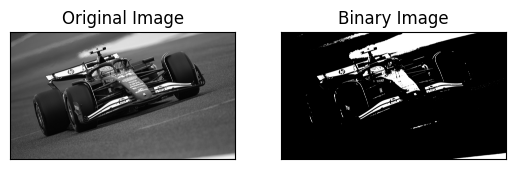

In [4]:
plt.subplot(121),plt.imshow(image,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(binary_image,cmap = 'gray')
plt.title('Binary Image'), plt.xticks([]), plt.yticks([])
 

Region Based Method

- Region-based segmentation involves dividing an image into regions with similar characteristics. Each region is a group of pixels, which the algorithm locates via a seed point. Once the algorithm finds the seed points, it can grow regions by adding more pixels or shrinking and merging them with other points.

In [12]:
image = cv.imread('/home/lucifer/Documents/Tech_Manthan/Image-Segmentation/micro.jpg')
gray = cv.cvtColor(image,cv.COLOR_BGR2GRAY)

ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Morphological cleaning
kernel = np.ones((3, 3), np.uint8)
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)

# Sure background
sure_bg = cv.dilate(opening, kernel, iterations=3)

# Sure foreground
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
ret, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)

# Marker labeling
ret, markers = cv.connectedComponents(sure_fg)

# Markers should be int32
markers = np.int32(markers)

# Increase all labels by 1
markers = markers + 1

# Mark unknown regions with 0
markers[unknown == 255] = 0

# Apply watershed
cv.watershed(image, markers)

# Boundary marked with -1
image[markers == -1] = [0, 0, 255]

# Save result
cv.imwrite("output.png", image)


True

In [25]:
img_path = '/home/lucifer/Documents/Tech_Manthan/Image-Segmentation/micro.jpg'
original_image = cv.imread(img_path,cv.IMREAD_GRAYSCALE)
fixed_width = 100
fixed_height = 50
resized_image = cv.resize(original_image,(fixed_width,fixed_height))
blurred_image = cv.GaussianBlur(original_image,(5,5),0)

def nothing(x):
    pass

cv.namedWindow('Canny Edge Window')

cv.createTrackbar('Lower Threshold','Canny Edge Window',0,255,nothing)
cv.createTrackbar('Upper Threshold','Canny Edge Window',0,255,nothing)

while True:
    lower = cv.getTrackbarPos('Lower Threshold','Canny Edge Window')
    upper = cv.getTrackbarPos('Upper Threshold','Canny Edge Window')
    edges = cv.Canny(blurred_image,lower,upper)

    cv.imshow('Canny Edge Window',edges)

    if cv.waitKey(1) & 0xFF == 27:
        break
cv.destroyAllWindows()


# edges = cv.Canny(blurred_image,30,70)

(Text(0.5, 1.0, 'Canny Edge Image'), ([], []), ([], []))

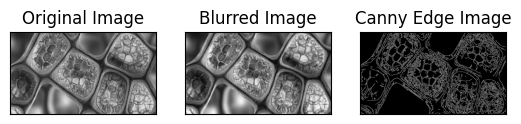

In [26]:
plt.subplot(1,3,1),plt.imshow(original_image,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,2),plt.imshow(blurred_image,cmap = 'gray')
plt.title('Blurred Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1,3,3),plt.imshow(edges,cmap='gray')
plt.title('Canny Edge Image'), plt.xticks([]), plt.yticks([])

 

Clustering Based Method

In [27]:
img_path = '/home/lucifer/Documents/Tech_Manthan/Image-Segmentation/car.jpg'
image = cv.imread(img_path)

pixels = image.reshape((-1,3))

pixels = np.float32(pixels)

# define criteria and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,100,0.2)
k = 3 # no of clusters
_,labels,centers = cv.kmeans(pixels,k,None,criteria,10,cv.KMEANS_RANDOM_CENTERS)

# Convert back to 8-bit values
centers = np.uint8(centers)

# map the labels to their corresponding center values
segmented_image = centers[labels.flatten()]

# reshape back to original image shape
segmented_image = segmented_image.reshape(image.shape)

cv.imwrite('Segmented_image.png',segmented_image)


True